<a href="https://colab.research.google.com/github/Thjnh725/Practice_Deep_Learning/blob/main/Linear_Regression_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import os
import copy
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

torch.manual_seed(42)
np.random.seed(42)

print("=" * 60)
print("ĐANG TẢI DỮ LIỆU TỪ KAGGLE...")
print("=" * 60)

path = kagglehub.dataset_download(
    "aiexplorer77/academic-performance-prediction"
)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("Không tìm thấy file CSV!")

csv_path = os.path.join(path, csv_files[0])

df = pd.read_csv(csv_path)

print(f"Tải thành công dataset với {len(df)} dòng dữ liệu")

ĐANG TẢI DỮ LIỆU TỪ KAGGLE...
Using Colab cache for faster access to the 'academic-performance-prediction' dataset.
Tải thành công dataset với 3000 dòng dữ liệu


In [44]:
print("\n" + "=" * 60)
print("TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 60)

df = df.dropna()

drop_cols = ['student_id', 'performance_category']

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

target_col = 'final_exam_score'

X_raw = df.drop(columns=[target_col])
y = df[target_col].values.astype(np.float32).reshape(-1, 1)

numeric_cols = [
    'age',
    'study_hours_per_day',
    'deep_work_sessions',
    'assignment_completion_rate',
    'attendance_percentage',
    'social_media_hours'
]

categorical_cols = [
    'gender',
    'city_type',
    'doomscrolling_before_sleep'
]


scaler = StandardScaler()

X_numeric_scaled = scaler.fit_transform(
    X_raw[numeric_cols]
)

X_cat_encoded = pd.get_dummies(
    X_raw[categorical_cols],
    drop_first=True
).astype(np.float32)

X_all = np.hstack([
    X_numeric_scaled,
    X_cat_encoded.values
])

print(f"Số lượng feature đầu vào: {X_all.shape[1]}")



TIỀN XỬ LÝ DỮ LIỆU
Số lượng feature đầu vào: 10


In [45]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
batch_size = 32

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [48]:
class AcademicPerformanceModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model = AcademicPerformanceModel(
    input_dim=X_train.shape[1]
)

print("\nKIẾN TRÚC MÔ HÌNH:")
print(model)


KIẾN TRÚC MÔ HÌNH:
AcademicPerformanceModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [49]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [50]:
epochs = 300

train_losses = []
val_losses = []

# Early stopping
patience = 15
min_delta = 0.001

best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0

print("\n" + "=" * 60)
print("BẮT ĐẦU HUẤN LUYỆN")
print("=" * 60)

for epoch in range(epochs):

    model.train()

    running_train_loss = 0.0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * batch_X.size(0)
        )

    epoch_train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

    train_losses.append(epoch_train_loss)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            predictions = model(batch_X)

            loss = criterion(predictions, batch_y)

            running_val_loss += (
                loss.item() * batch_X.size(0)
            )

    epoch_val_loss = (
        running_val_loss / len(val_loader.dataset)
    )

    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1:03d}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    if epoch_val_loss < (best_val_loss - min_delta):

        best_val_loss = epoch_val_loss

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1

    if patience_counter >= patience:

        print("\nEARLY STOPPING ĐƯỢC KÍCH HOẠT!")
        print(f"Dừng tại epoch: {epoch + 1}")

        break



BẮT ĐẦU HUẤN LUYỆN
Epoch [001/300] | Train Loss: 3147.4772 | Val Loss: 2956.6110 | LR: 0.001000
Epoch [010/300] | Train Loss: 355.1179 | Val Loss: 317.6603 | LR: 0.001000
Epoch [020/300] | Train Loss: 325.6770 | Val Loss: 287.5737 | LR: 0.001000
Epoch [030/300] | Train Loss: 308.4504 | Val Loss: 288.2167 | LR: 0.001000
Epoch [040/300] | Train Loss: 304.7717 | Val Loss: 289.0476 | LR: 0.001000
Epoch [050/300] | Train Loss: 303.5856 | Val Loss: 283.1719 | LR: 0.000500
Epoch [060/300] | Train Loss: 311.3266 | Val Loss: 283.9513 | LR: 0.000250

EARLY STOPPING ĐƯỢC KÍCH HOẠT!
Dừng tại epoch: 69


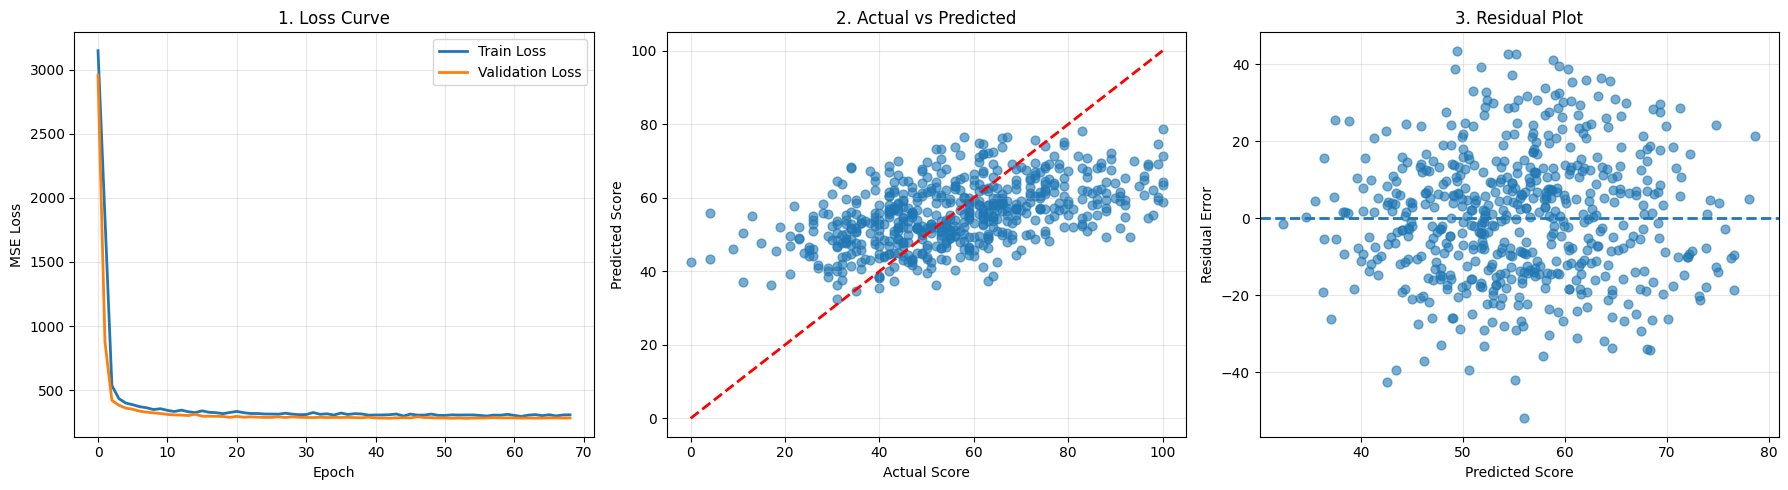

In [55]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

plt.plot(
    train_losses,
    label='Train Loss',
    linewidth=2
)

plt.plot(
    val_losses,
    label='Validation Loss',
    linewidth=2
)

plt.title('1. Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)

plt.scatter(
    all_true,
    all_preds,
    alpha=0.6,
    s=40
)

plt.plot(
    [all_true.min(), all_true.max()],
    [all_true.min(), all_true.max()],
    'r--',
    linewidth=2
)

plt.title('2. Actual vs Predicted')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')

plt.grid(True, alpha=0.3)

residuals = all_true - all_preds

plt.subplot(1, 3, 3)

plt.scatter(
    all_preds,
    residuals,
    alpha=0.6,
    s=40
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.title('3. Residual Plot')
plt.xlabel('Predicted Score')
plt.ylabel('Residual Error')

plt.grid(True, alpha=0.3)

# ---------------------------------------------------------
plt.tight_layout()
plt.show()
